<>:98: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\p'
<>:99: SyntaxWarning: invalid escape sequence '\o'
<>:98: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\p'
<>:98: SyntaxWarning: invalid escape sequence '\p'
<>:99: SyntaxWarning: invalid escape sequence '\o'
C:\Users\webbd\AppData\Local\Temp\ipykernel_26240\4227304310.py:98: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi], ["$-\pi$", "$-\pi/2$", "0", "$\pi/2$", "$\pi$"])
C:\Users\webbd\AppData\Local\Temp\ipykernel_26240\4227304310.py:98: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi], ["$-\pi$", "$-\pi/2$", "0", "$\pi/2$", "$\pi$"])
C:\Users\webbd\AppData\Local\Temp\ipykernel_26240\422730

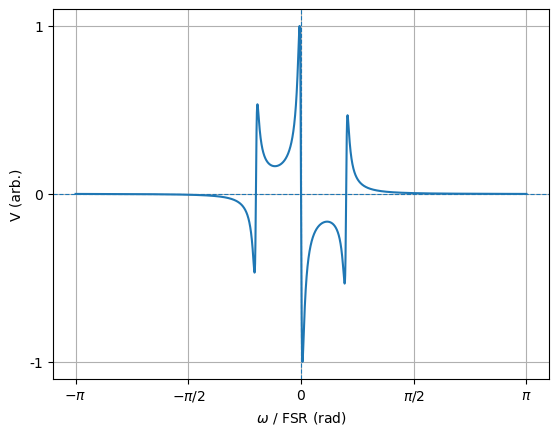

In [18]:
import numpy as np
import matplotlib.pyplot as plt


def cavity_reflection_phase(u, r1, r2):
    """
    Complex amplitude reflection coefficient of a lossless Fabry-Perot cavity.

    u  = round-trip phase detuning, in radians
       = 2 * Delta * L / c
       = 2*pi * df / FSR

    r1 = input mirror amplitude reflectivity
    r2 = end mirror amplitude reflectivity
    """
    return (r1 - r2 * np.exp(1j * u)) / (1 - r1 * r2 * np.exp(1j * u))


def v_pdh(
    x,
    r1=0.99,
    r2=0.99,
    omega_phase=0.3,
    demod_phase=np.pi / 2,
    amplitude=1.0,
):
    """
    Full first-order PDH error signal.

    x = carrier round-trip phase detuning, radians
      = 2*pi * df / FSR

    omega_phase = modulation round-trip phase, radians
                = 2*pi * f_mod / FSR

    demod_phase = RF demodulation phase, radians

    amplitude absorbs:
        photodiode gain,
        transimpedance,
        mixer gain,
        input power,
        J0(beta) J1(beta),
        etc.
    """

    r_carrier = cavity_reflection_phase(x, r1, r2)
    r_upper = cavity_reflection_phase(x + omega_phase, r1, r2)
    r_lower = cavity_reflection_phase(x - omega_phase, r1, r2)

    F = r_carrier * np.conj(r_upper) - np.conj(r_carrier) * r_lower

    return amplitude * np.real(F * np.exp(-1j * demod_phase))

def finesse_from_r(r1, r2):
    """
    Finesse of a lossless two-mirror Fabry-Perot cavity.

    r1, r2 are amplitude reflectivities, not power reflectivities.
    """
    g = r1 * r2
    return np.pi * np.sqrt(g) / (1 - g)
# -----------------------------
# Example: plot versus phase detuning
# -----------------------------

r1 = 0.99
r2 = 0.99

A = 1.0

# Modulation frequency in units of FSR
f_mod_over_fsr = 0.10
omega_phase = 2 * np.pi * f_mod_over_fsr

# Demodulation phase
demod_phase = np.pi / 2

x = np.linspace(-np.pi, np.pi, 4000)

V = v_pdh(
    x,
    r1=r1,
    r2=r2,
    omega_phase=omega_phase,
    demod_phase=demod_phase,
    amplitude=A,
)

plt.figure()
plt.plot(x, V)
plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axvline(0, linestyle="--", linewidth=0.8)
# y axis limits
plt.ylim(-1.1 * A, 1.1 * A)
# y labels
plt.yticks([-1, 0, 1], ["-1", "0", "1"])
plt.xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi], ["$-\pi$", "$-\pi/2$", "0", "$\pi/2$", "$\pi$"])
plt.xlabel("$\omega$ / FSR (rad)")
plt.ylabel("V (arb.)")
plt.grid(True)
plt.show()

Finesse = 3926.21
FSR = 1498.962 MHz, f_mod = 5.000 MHz


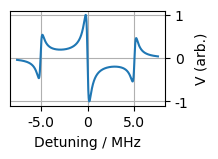

In [42]:
# -----------------------------
# Example: plot versus frequency detuning
# -----------------------------

L = 0.10          # cavity length in metres
c = 299_792_458  # speed of light, m/s

FSR = c / (2 * L)

r1 = 0.9996
r2 = 0.9996

F = finesse_from_r(r1, r2)
print(f"Finesse = {F:.2f}")

f_mod = 5e6     # modulation frequency, Hz
print(f"FSR = {FSR/10**6:.3f} MHz, f_mod = {f_mod/10**6:.3f} MHz")
omega_phase = 2 * np.pi * f_mod / FSR

df = np.linspace(-1.5*f_mod, 1.5*f_mod, 4000)

x = 2 * np.pi * df / FSR

V = v_pdh(
    x,
    r1=r1,
    r2=r2,
    omega_phase=omega_phase,
    demod_phase=np.pi / 2,
    amplitude=1.0,
)
# fig size
width = 2
height = width * 0.618  # golden ratio
plt.figure(figsize=(width, height))
plt.plot(df, V)
plt.ylim(-1.1 * A, 1.1 * A)
plt.gca().yaxis.set_label_position("right")
# y ticks on right-hand side
plt.gca().yaxis.tick_right()
plt.yticks([-1, 0, 1], ["-1", "0", "1"])
plt.xticks([-f_mod, 0, f_mod], [f"{-f_mod/1e6}", "0", f"{f_mod/1e6}"])
plt.xlabel("Detuning / MHz")
plt.ylabel("V (arb.)")
plt.grid(True)
# save fig as pdf
plt.savefig("pdh_error_signal.pdf", bbox_inches="tight")